# Part 4: Tiền xử lý dữ liệu thời gian (Temporal Data Preprocessing) - BONUS

## Thông tin nhóm
- **Tên nhóm:** 05
- **Thành viên:**
  - Bùi Minh Duy - 23127040
  - Phi Anh Khôi - 23127073
  - Lê Minh Đức - 23127351


## 1. Mô tả Dataset

**Tên:** NASDAQ Stock Market Data (AAPL)

**Nguồn:** [Kaggle - Stock Market Dataset](https://www.kaggle.com/datasets)

**Kích thước:** Dữ liệu giá cổ phiếu hàng ngày từ năm 1980 đến 2022 (>40 năm)

**Mô tả:** Dataset chứa thông tin giá cổ phiếu theo ngày của Apple Inc. trên sàn NASDAQ:
- **AAPL**: Apple Inc. - công ty công nghệ hàng đầu thế giới

**Các cột dữ liệu:**
- `Date`: Ngày giao dịch
- `Open`: Giá mở cửa
- `High`: Giá cao nhất trong ngày
- `Low`: Giá thấp nhất trong ngày
- `Close`: Giá đóng cửa
- `Adjusted Close`: Giá đóng cửa đã điều chỉnh
- `Volume`: Khối lượng giao dịch

In [52]:
# Import thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import interpolate
import warnings
from pandas.tseries.holiday import USFederalHolidayCalendar
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print("Đã load thành công các thư viện!")


Đã load thành công các thư viện!


## 2. Load Data

Trong phần này, chúng ta sẽ load dữ liệu từ 3 file CSV chứa thông tin cổ phiếu của AAPL, MSFT và TSLA.

In [53]:
# Đường dẫn đến các file dữ liệu
data_path = '../data/temporal/stock_market_data/nasdaq/csv/'

# Load dữ liệu AAPL
aapl_raw = pd.read_csv(data_path + 'AAPL.csv')

print("THỐNG KÊ DỮ LIỆU THÔ")
print("="*60)
print(f"AAPL: {len(aapl_raw):,} dòng, {aapl_raw.shape[1]} cột")
print("="*60)

# Hiển thị mẫu dữ liệu AAPL
print("\nAAPL - Dữ liệu mẫu:")
display(aapl_raw.head())

print("\nAAPL - Thông tin kiểu dữ liệu:")
display(aapl_raw.info())


THỐNG KÊ DỮ LIỆU THÔ
AAPL: 10,590 dòng, 7 cột

AAPL - Dữ liệu mẫu:


,Date,Low,Open,Volume,High,Close,Adjusted Close
0,12-12-1980,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,15-12-1980,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,16-12-1980,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,17-12-1980,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,18-12-1980,0.118862,0.118862,73449600,0.119420,0.118862,0.092492



AAPL - Thông tin kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10590 entries, 0 to 10589
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            10590 non-null  object 
 1   Low             10590 non-null  float64
 2   Open            10590 non-null  float64
 3   Volume          10590 non-null  int64  
 4   High            10590 non-null  float64
 5   Close           10590 non-null  float64
 6   Adjusted Close  10590 non-null  float64
dtypes: float64(5), int64(1), object(1)
memory usage: 579.3+ KB


None

---

# 3. Parsing Date and Time (Xử lý Ngày Tháng)

### Mục đích:
- Chuyển đổi chuỗi ký tự ngày tháng thành đối tượng datetime
- Xử lý nhiều định dạng ngày tháng khác nhau
- Trích xuất các thành phần thời gian (năm, tháng, ngày, ngày trong tuần)
- Thiết lập index dạng datetime cho time series

### Giải thích:
Datetime parsing là bước quan trọng đầu tiên khi làm việc với dữ liệu thời gian. Pandas cung cấp hàm `pd.to_datetime()` có khả năng:
- Tự động nhận diện nhiều format (DD-MM-YYYY, YYYY-MM-DD, MM/DD/YYYY, ...)
- Xử lý lỗi một cách linh hoạt
- Hỗ trợ multiple formats trong cùng một cột


In [54]:
# Hàm kiểm tra định dạng ngày tháng trong dữ liệu
def analyze_date_format(df, date_col='Date'):
    """
    Phân tích định dạng ngày tháng trong DataFrame
    """
    print(f"Phân tích định dạng cột '{date_col}':")
    print("-" * 50)
    print(f"Kiểu dữ liệu hiện tại: {df[date_col].dtype}")
    print(f"\nMẫu giá trị:")
    print(df[date_col].head(10).tolist())
    print(f"\nSố giá trị null: {df[date_col].isna().sum()}")
    print(f"Số giá trị unique: {df[date_col].nunique():,}")
    
# Phân tích định dạng ngày của AAPL
analyze_date_format(aapl_raw)


Phân tích định dạng cột 'Date':
--------------------------------------------------
Kiểu dữ liệu hiện tại: object

Mẫu giá trị:
['12-12-1980', '15-12-1980', '16-12-1980', '17-12-1980', '18-12-1980', '19-12-1980', '22-12-1980', '23-12-1980', '24-12-1980', '26-12-1980']

Số giá trị null: 0
Số giá trị unique: 10,590


In [55]:
# Parse datetime cho AAPL với error handling
print("Đang parse datetime cho AAPL...")

# Tạo bản sao để xử lý
aapl_df = aapl_raw.copy()

# Parse datetime - pandas tự động nhận dạng format DD-MM-YYYY
aapl_df['Date'] = pd.to_datetime(aapl_df['Date'], format='%d-%m-%Y', errors='coerce')

# Kiểm tra kết quả parsing
print(f"Parsing hoàn tất!")
print(f"Số giá trị không parse được (NaT): {aapl_df['Date'].isna().sum()}")
print(f"\nKiểu dữ liệu mới: {aapl_df['Date'].dtype}")
print(f"\nKhoảng thời gian dữ liệu:")
print(f"  - Từ ngày: {aapl_df['Date'].min()}")
print(f"  - Đến ngày: {aapl_df['Date'].max()}")
print(f"  - Tổng số ngày: {(aapl_df['Date'].max() - aapl_df['Date'].min()).days:,} ngày")

# Hiển thị mẫu dữ liệu sau khi parse
print("\nDữ liệu sau khi parse:")
display(aapl_df[['Date', 'Close', 'Volume']].head(10))


Đang parse datetime cho AAPL...
Parsing hoàn tất!
Số giá trị không parse được (NaT): 0

Kiểu dữ liệu mới: datetime64[ns]

Khoảng thời gian dữ liệu:
  - Từ ngày: 1980-12-12 00:00:00
  - Đến ngày: 2022-12-12 00:00:00
  - Tổng số ngày: 15,340 ngày

Dữ liệu sau khi parse:


,Date,Close,Volume
0,1980-12-12,0.128348,469033600
1,1980-12-15,0.121652,175884800
2,1980-12-16,0.112723,105728000
3,1980-12-17,0.115513,86441600
4,1980-12-18,0.118862,73449600
5,1980-12-19,0.126116,48630400
6,1980-12-22,0.132254,37363200
7,1980-12-23,0.137835,46950400
8,1980-12-24,0.145089,48003200
9,1980-12-26,0.158482,55574400


In [56]:
# Sắp xếp theo thứ tự thời gian và reset index
aapl_df = aapl_df.sort_values('Date').reset_index(drop=True)

# Thiết lập datetime index cho time series
aapl_df.set_index('Date', inplace=True)

print("Đã set datetime index cho AAPL")
print(f"\nIndex type: {type(aapl_df.index)}")
print(f"Index name: {aapl_df.index.name}")
print(f"\nThông tin index:")
print(aapl_df.index)

# Hiển thị dữ liệu với datetime index
print("\nDữ liệu với datetime index:")
display(aapl_df.head())


Đã set datetime index cho AAPL

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index name: Date

Thông tin index:
DatetimeIndex(['1980-12-12', '1980-12-15', '1980-12-16', '1980-12-17',
               '1980-12-18', '1980-12-19', '1980-12-22', '1980-12-23',
               '1980-12-24', '1980-12-26',
               ...
               '2022-11-29', '2022-11-30', '2022-12-01', '2022-12-02',
               '2022-12-05', '2022-12-06', '2022-12-07', '2022-12-08',
               '2022-12-09', '2022-12-12'],
              dtype='datetime64[ns]', name='Date', length=10590, freq=None)

Dữ liệu với datetime index:


,Low,Open,Volume,High,Close,Adjusted Close
Date,,,,,,
1980-12-12,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1980-12-15,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
1980-12-16,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
1980-12-17,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
1980-12-18,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


### Trích xuất các thành phần thời gian (Time Components)

Từ datetime index, chúng ta có thể trích xuất nhiều thông tin hữu ích:
- **Year, Month, Day**: Để phân tích theo chu kỳ
- **Day of Week**: Để phát hiện pattern theo ngày trong tuần (0=Monday, 6=Sunday)
- **Quarter**: Để phân tích theo quý
- **Week of Year**: Để phân tích theo tuần

In [57]:
# Trích xuất các thành phần thời gian
aapl_df['Year'] = aapl_df.index.year
aapl_df['Month'] = aapl_df.index.month
aapl_df['Day'] = aapl_df.index.day
aapl_df['DayOfWeek'] = aapl_df.index.dayofweek  # 0=Monday, 6=Sunday
aapl_df['DayName'] = aapl_df.index.day_name()   # Tên ngày
aapl_df['Quarter'] = aapl_df.index.quarter
aapl_df['WeekOfYear'] = aapl_df.index.isocalendar().week

print("Đã trích xuất các thành phần thời gian")
print("\nDữ liệu với time components:")
display(aapl_df[['Close', 'Year', 'Month', 'Day', 'DayOfWeek', 'DayName', 'Quarter']].head(10))

# Thống kê phân bố theo các thành phần thời gian
print("\nPhân bố dữ liệu theo năm:")
year_counts = aapl_df['Year'].value_counts().sort_index()
print(year_counts.head(10))

print("\nPhân bố dữ liệu theo ngày trong tuần:")
day_counts = aapl_df['DayName'].value_counts()
print(day_counts)


Đã trích xuất các thành phần thời gian

Dữ liệu với time components:


,Close,Year,Month,Day,DayOfWeek,DayName,Quarter
Date,,,,,,,
1980-12-12,0.128348,1980,12,12,4,Friday,4
1980-12-15,0.121652,1980,12,15,0,Monday,4
1980-12-16,0.112723,1980,12,16,1,Tuesday,4
1980-12-17,0.115513,1980,12,17,2,Wednesday,4
1980-12-18,0.118862,1980,12,18,3,Thursday,4
1980-12-19,0.126116,1980,12,19,4,Friday,4
1980-12-22,0.132254,1980,12,22,0,Monday,4
1980-12-23,0.137835,1980,12,23,1,Tuesday,4
1980-12-24,0.145089,1980,12,24,2,Wednesday,4



Phân bố dữ liệu theo năm:
Year
1980     13
1981    253
1982    253
1983    253
1984    253
1985    252
1986    253
1987    253
1988    253
1989    252
Name: count, dtype: int64

Phân bố dữ liệu theo ngày trong tuần:
DayName
Tuesday      2171
Wednesday    2170
Thursday     2130
Friday       2115
Monday       2004
Name: count, dtype: int64


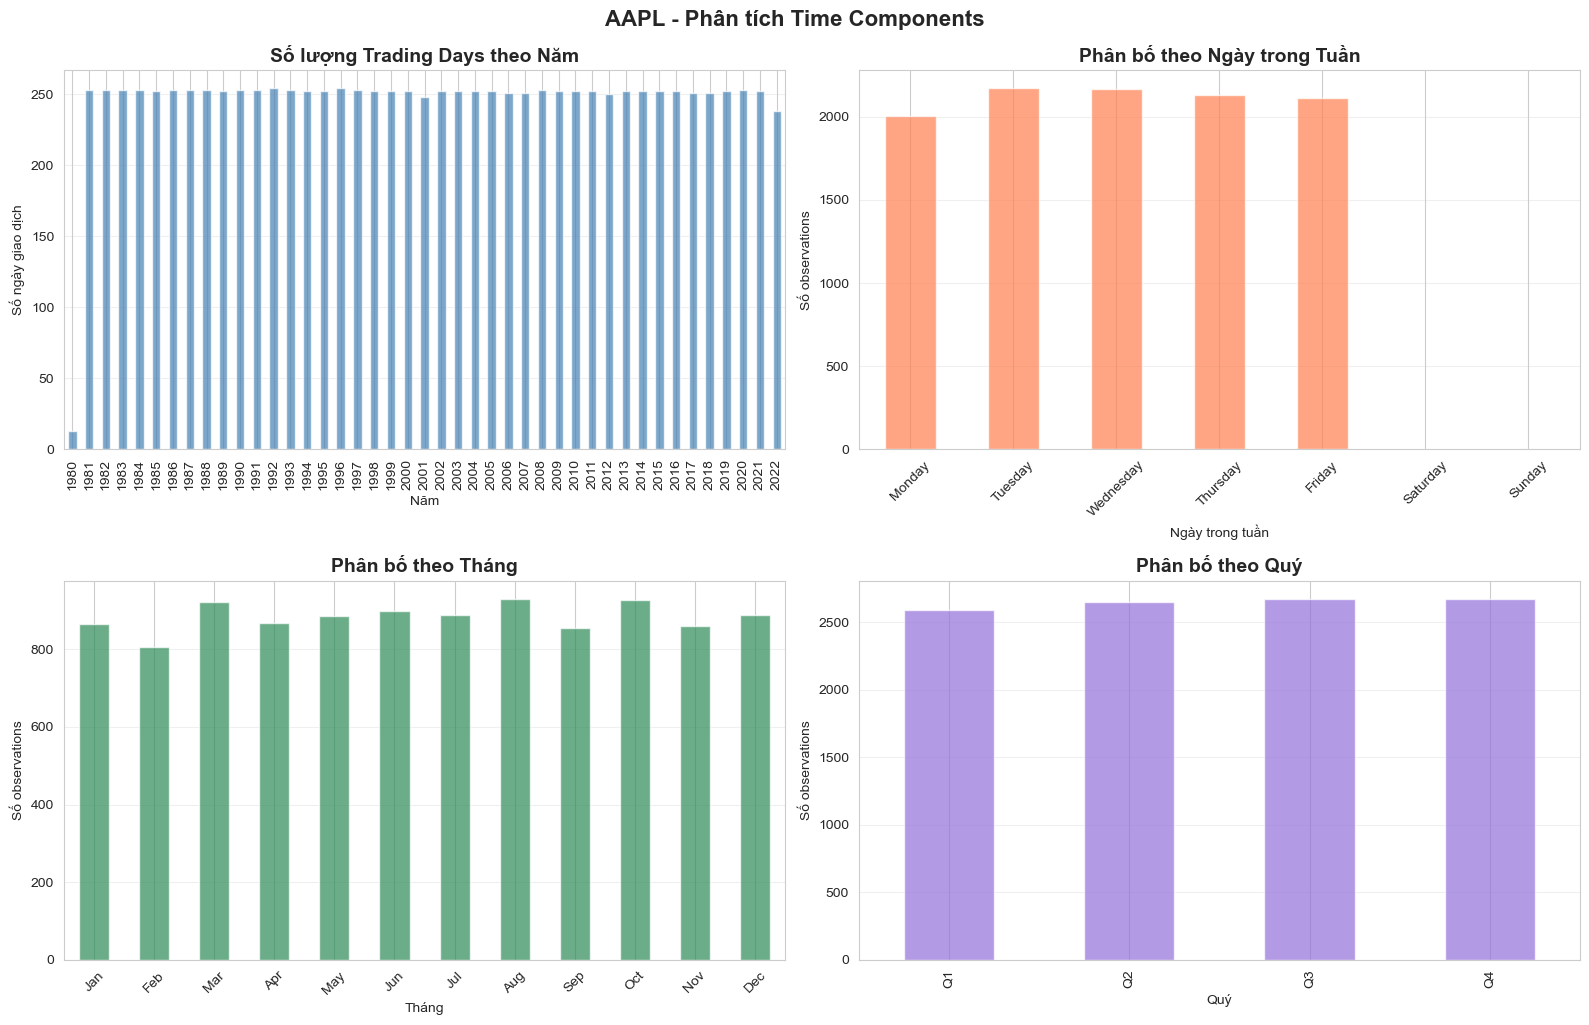


Nhận xét:
- Thị trường chứng khoán chỉ giao dịch từ Thứ Hai đến Thứ Sáu
- Mỗi năm thường có khoảng 252 ngày giao dịch (trừ cuối tuần và ngày lễ)
- Phân bố tương đối đồng đều theo tháng và quý


In [58]:
# Visualization 1: Phân bố dữ liệu theo năm
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Số lượng observations theo năm
year_counts.plot(kind='bar', ax=axes[0, 0], color='steelblue', alpha=0.7)
axes[0, 0].set_title('Số lượng Trading Days theo Năm', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Năm')
axes[0, 0].set_ylabel('Số ngày giao dịch')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Phân bố theo ngày trong tuần
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts_ordered = aapl_df['DayName'].value_counts().reindex(day_order, fill_value=0)
day_counts_ordered.plot(kind='bar', ax=axes[0, 1], color='coral', alpha=0.7)
axes[0, 1].set_title('Phân bố theo Ngày trong Tuần', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Ngày trong tuần')
axes[0, 1].set_ylabel('Số observations')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Phân bố theo tháng
month_counts = aapl_df['Month'].value_counts().sort_index()
month_counts.plot(kind='bar', ax=axes[1, 0], color='seagreen', alpha=0.7)
axes[1, 0].set_title('Phân bố theo Tháng', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Tháng')
axes[1, 0].set_ylabel('Số observations')
axes[1, 0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                             'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Phân bố theo quý
quarter_counts = aapl_df['Quarter'].value_counts().sort_index()
quarter_counts.plot(kind='bar', ax=axes[1, 1], color='mediumpurple', alpha=0.7)
axes[1, 1].set_title('Phân bố theo Quý', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Quý')
axes[1, 1].set_ylabel('Số observations')
axes[1, 1].set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('AAPL - Phân tích Time Components', fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("\nNhận xét:")
print("- Thị trường chứng khoán chỉ giao dịch từ Thứ Hai đến Thứ Sáu")
print("- Mỗi năm thường có khoảng 252 ngày giao dịch (trừ cuối tuần và ngày lễ)")
print("- Phân bố tương đối đồng đều theo tháng và quý")


---

# 4. Handling Time Gaps (Xử lý Khoảng Trống Thời Gian)

### Mục đích:
- Xác định các khoảng trống (missing timestamps) trong chuỗi thời gian
- So sánh các phương pháp fill gaps: Forward Fill, Backward Fill, Interpolation
- Đánh giá hiệu quả của từng phương pháp

### Lý thuyết:
1. **Forward Fill (ffill)**: Điền giá trị từ observation trước đó
   - Ưu điểm: Đơn giản, giữ nguyên giá trị thực tế
   - Nhược điểm: Có thể tạo ra "bậc thang" trong dữ liệu

2. **Backward Fill (bfill)**: Điền giá trị từ observation sau
   - Ưu điểm: Đơn giản, hữu ích khi muốn "nhìn về tương lai"
   - Nhược điểm: Không phù hợp với time series thực tế (leak information)

3. **Linear Interpolation**: Nội suy tuyến tính giữa 2 điểm
   - Ưu điểm: Smooth, phù hợp với dữ liệu có xu hướng tuyến tính
   - Nhược điểm: Không nắm bắt được pattern phi tuyến

4. **Polynomial Interpolation**: Nội suy đa thức bậc cao
   - Ưu điểm: Nắm bắt được pattern phức tạp hơn
   - Nhược điểm: Có thể overfitting, tạo ra giá trị không hợp lý

5. **Spline Interpolation**: Nội suy sử dụng spline functions
   - Ưu điểm: Smooth, linh hoạt, ít overfitting hơn polynomial
   - Nhược điểm: Phức tạp hơn, cần nhiều tính toán


In [59]:
# Bước 1: Xác định missing timestamps
print("PHÂN TÍCH TIME GAPS")
print("="*70)

# Tạo range đầy đủ của tất cả các ngày (bao gồm cả cuối tuần)
date_range_all = pd.date_range(start=aapl_df.index.min(), 
                                end=aapl_df.index.max(), 
                                freq='D')

# Tìm missing dates
missing_dates = date_range_all.difference(aapl_df.index)

print(f"Tổng số ngày trong khoảng thời gian: {len(date_range_all):,}")
print(f"Số ngày có dữ liệu: {len(aapl_df):,}")
print(f"Số ngày bị thiếu: {len(missing_dates):,}")
print(f"Tỷ lệ missing: {len(missing_dates)/len(date_range_all)*100:.2f}%")

# Phân tích missing dates theo ngày trong tuần
print("\nPhân bố missing dates theo ngày trong tuần:")
missing_daynames = pd.Series(missing_dates).dt.day_name().value_counts()
print(missing_daynames)

print("\nNhận xét:")
print("- Phần lớn missing dates là cuối tuần (Saturday & Sunday)")
print("- Còn lại là các ngày lễ của thị trường chứng khoán Mỹ")


PHÂN TÍCH TIME GAPS
Tổng số ngày trong khoảng thời gian: 15,341
Số ngày có dữ liệu: 10,590
Số ngày bị thiếu: 4,751
Tỷ lệ missing: 30.97%

Phân bố missing dates theo ngày trong tuần:
Saturday     2192
Sunday       2192
Monday        188
Friday         77
Thursday       61
Wednesday      21
Tuesday        20
Name: count, dtype: int64

Nhận xét:
- Phần lớn missing dates là cuối tuần (Saturday & Sunday)
- Còn lại là các ngày lễ của thị trường chứng khoán Mỹ


In [60]:
# Bước 2: Tạo DataFrame với full date range để có gaps
print("Tạo DataFrame với đầy đủ date range...")

# Chỉ lấy cột Close để demo rõ ràng hơn
aapl_close = aapl_df[['Close']].copy()

# Reindex với tất cả các ngày
aapl_with_gaps = aapl_close.reindex(date_range_all)

print(f"Đã tạo DataFrame với {len(aapl_with_gaps):,} rows")
print(f"Số giá trị missing: {aapl_with_gaps['Close'].isna().sum():,}")
print(f"\nMẫu dữ liệu với gaps (cuối tuần):")
# Hiển thị một tuần để thấy gaps
sample_week = aapl_with_gaps['2022-01-03':'2022-01-09']
display(sample_week)


Tạo DataFrame với đầy đủ date range...
Đã tạo DataFrame với 15,341 rows
Số giá trị missing: 4,751

Mẫu dữ liệu với gaps (cuối tuần):


,Close
2022-01-03,182.009995
2022-01-04,179.699997
2022-01-05,174.919998
2022-01-06,172.000000
2022-01-07,172.169998
2022-01-08,NaN
2022-01-09,NaN


In [61]:
# Bước 3: Áp dụng các phương pháp fill gaps
print("Áp dụng các phương pháp điền gaps...\n")

# Method 1: Forward Fill
aapl_ffill = aapl_with_gaps.copy()
aapl_ffill['Close_ffill'] = aapl_ffill['Close'].fillna(method='ffill')
print("Forward Fill complete")

# Method 2: Backward Fill
aapl_bfill = aapl_with_gaps.copy()
aapl_bfill['Close_bfill'] = aapl_bfill['Close'].fillna(method='bfill')
print("Backward Fill complete")

# Method 3: Linear Interpolation
aapl_linear = aapl_with_gaps.copy()
aapl_linear['Close_linear'] = aapl_linear['Close'].interpolate(method='linear')
print("Linear Interpolation complete")

# Method 4: Polynomial Interpolation (bậc 2)
aapl_poly = aapl_with_gaps.copy()
aapl_poly['Close_poly'] = aapl_poly['Close'].interpolate(method='polynomial', order=2)
print("Polynomial Interpolation complete")

# Method 5: Spline Interpolation
aapl_spline = aapl_with_gaps.copy()
aapl_spline['Close_spline'] = aapl_spline['Close'].interpolate(method='spline', order=2)
print("Spline Interpolation complete")

# Kết hợp tất cả vào một DataFrame để so sánh
comparison_df = pd.DataFrame({
    'Original': aapl_with_gaps['Close'],
    'Forward_Fill': aapl_ffill['Close_ffill'],
    'Backward_Fill': aapl_bfill['Close_bfill'],
    'Linear': aapl_linear['Close_linear'],
    'Polynomial': aapl_poly['Close_poly'],
    'Spline': aapl_spline['Close_spline']
})

print("\nSo sánh các phương pháp trong một tuần:")
display(comparison_df['2022-01-03':'2022-01-11'].round(2))


Áp dụng các phương pháp điền gaps...

Forward Fill complete
Backward Fill complete
Linear Interpolation complete
Polynomial Interpolation complete
Spline Interpolation complete

So sánh các phương pháp trong một tuần:


,Original,Forward_Fill,Backward_Fill,Linear,Polynomial,Spline
2022-01-03,182.01,182.01,182.01,182.01,182.01,182.01
2022-01-04,179.70,179.70,179.70,179.70,179.70,179.70
2022-01-05,174.92,174.92,174.92,174.92,174.92,174.92
2022-01-06,172.00,172.00,172.00,172.00,172.00,172.00
2022-01-07,172.17,172.17,172.17,172.17,172.17,172.17
2022-01-08,NaN,172.17,172.19,172.18,171.92,174.53
2022-01-09,NaN,172.17,172.19,172.18,171.07,174.08
2022-01-10,172.19,172.19,172.19,172.19,172.19,172.19
2022-01-11,175.08,175.08,175.08,175.08,175.08,175.08


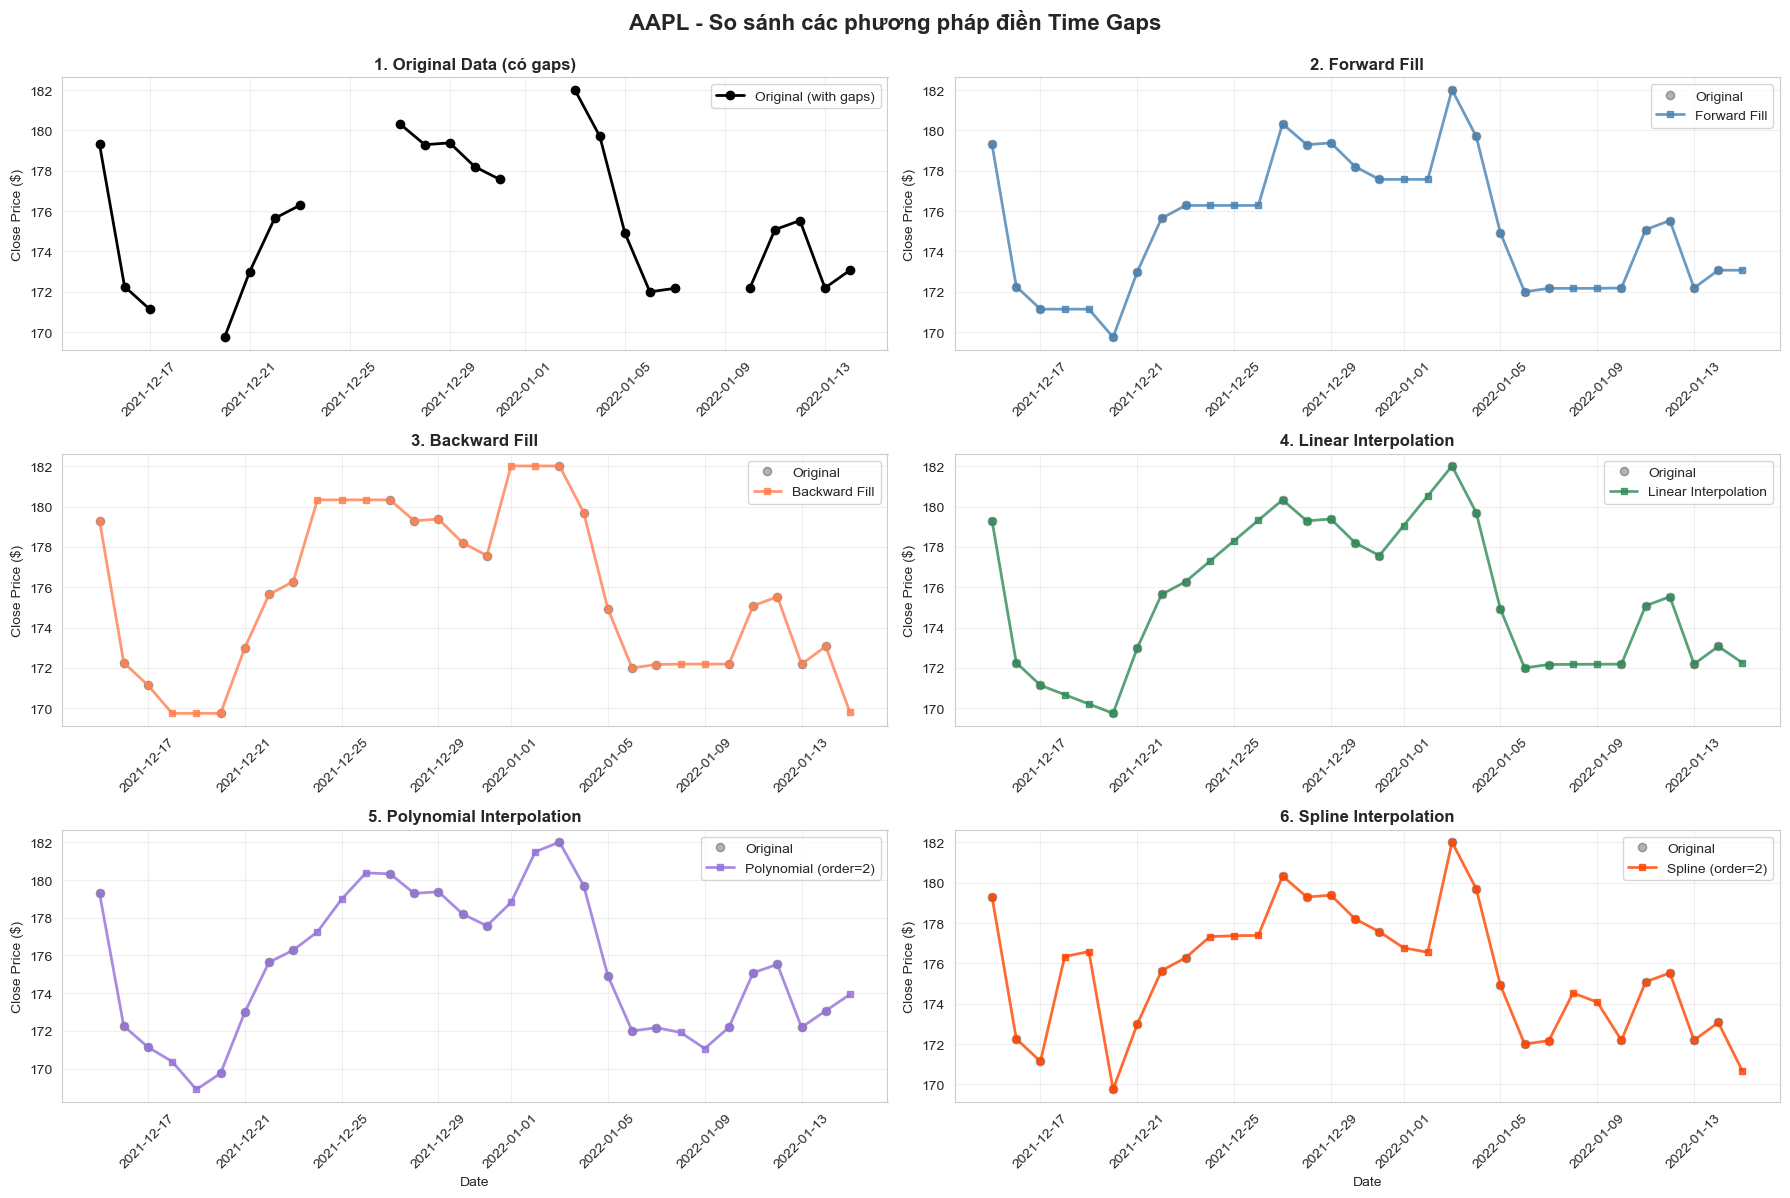

In [62]:
# Visualization: So sánh các phương pháp fill gaps
# Chọn một khoảng thời gian ngắn để dễ quan sát
start_date = '2021-12-15'
end_date = '2022-01-15'
plot_data = comparison_df[start_date:end_date]

fig, axes = plt.subplots(3, 2, figsize=(18, 12))
fig.suptitle('AAPL - So sánh các phương pháp điền Time Gaps', 
             fontsize=16, fontweight='bold', y=0.995)

# 1. Original with gaps
axes[0, 0].plot(plot_data.index, plot_data['Original'], 
                marker='o', linestyle='-', linewidth=2, markersize=6,
                color='black', label='Original (with gaps)')
axes[0, 0].set_title('1. Original Data (có gaps)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Close Price ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Forward Fill
axes[0, 1].plot(plot_data.index, plot_data['Original'], 
                marker='o', linestyle='', markersize=6,
                color='black', alpha=0.3, label='Original')
axes[0, 1].plot(plot_data.index, plot_data['Forward_Fill'], 
                marker='s', linestyle='-', linewidth=2, markersize=4,
                color='steelblue', label='Forward Fill', alpha=0.8)
axes[0, 1].set_title('2. Forward Fill', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Close Price ($)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Backward Fill
axes[1, 0].plot(plot_data.index, plot_data['Original'], 
                marker='o', linestyle='', markersize=6,
                color='black', alpha=0.3, label='Original')
axes[1, 0].plot(plot_data.index, plot_data['Backward_Fill'], 
                marker='s', linestyle='-', linewidth=2, markersize=4,
                color='coral', label='Backward Fill', alpha=0.8)
axes[1, 0].set_title('3. Backward Fill', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Close Price ($)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Linear Interpolation
axes[1, 1].plot(plot_data.index, plot_data['Original'], 
                marker='o', linestyle='', markersize=6,
                color='black', alpha=0.3, label='Original')
axes[1, 1].plot(plot_data.index, plot_data['Linear'], 
                marker='s', linestyle='-', linewidth=2, markersize=4,
                color='seagreen', label='Linear Interpolation', alpha=0.8)
axes[1, 1].set_title('4. Linear Interpolation', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Close Price ($)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

# 5. Polynomial Interpolation
axes[2, 0].plot(plot_data.index, plot_data['Original'], 
                marker='o', linestyle='', markersize=6,
                color='black', alpha=0.3, label='Original')
axes[2, 0].plot(plot_data.index, plot_data['Polynomial'], 
                marker='s', linestyle='-', linewidth=2, markersize=4,
                color='mediumpurple', label='Polynomial (order=2)', alpha=0.8)
axes[2, 0].set_title('5. Polynomial Interpolation', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Date')
axes[2, 0].set_ylabel('Close Price ($)')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].tick_params(axis='x', rotation=45)

# 6. Spline Interpolation
axes[2, 1].plot(plot_data.index, plot_data['Original'], 
                marker='o', linestyle='', markersize=6,
                color='black', alpha=0.3, label='Original')
axes[2, 1].plot(plot_data.index, plot_data['Spline'], 
                marker='s', linestyle='-', linewidth=2, markersize=4,
                color='orangered', label='Spline (order=2)', alpha=0.8)
axes[2, 1].set_title('6. Spline Interpolation', fontsize=12, fontweight='bold')
axes[2, 1].set_xlabel('Date')
axes[2, 1].set_ylabel('Close Price ($)')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [63]:
# Đánh giá hiệu quả: So sánh với giá trị thực tế
# Để đánh giá, ta sẽ tạo gaps giả và so sánh

print("ĐÁNH GIÁ HIỆU QUẢ CÁC PHƯƠNG PHÁP")
print("="*70)

# Lấy dữ liệu không có gaps
aapl_complete = aapl_close.copy()

# Tạo gaps giả: xóa một số giá trị ngẫu nhiên
np.random.seed(42)
test_indices = np.random.choice(aapl_complete.index[100:200], size=20, replace=False)
aapl_test = aapl_complete.copy()
aapl_test.loc[test_indices, 'Close'] = np.nan

# Lưu giá trị thực
true_values = aapl_complete.loc[test_indices, 'Close']

# Áp dụng các phương pháp
methods = {
    'Forward Fill': aapl_test['Close'].fillna(method='ffill'),
    'Backward Fill': aapl_test['Close'].fillna(method='bfill'),
    'Linear': aapl_test['Close'].interpolate(method='linear'),
    'Polynomial': aapl_test['Close'].interpolate(method='polynomial', order=2),
    'Spline': aapl_test['Close'].interpolate(method='spline', order=2)
}

# Tính toán metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []
for method_name, predictions in methods.items():
    pred_values = predictions.loc[test_indices]
    mae = mean_absolute_error(true_values, pred_values)
    rmse = np.sqrt(mean_squared_error(true_values, pred_values))
    mape = np.mean(np.abs((true_values - pred_values) / true_values)) * 100
    r2 = r2_score(true_values, pred_values)
    
    results.append({
        'Method': method_name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'R²': r2
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE')

print("\nKết quả đánh giá (sắp xếp theo RMSE - càng nhỏ càng tốt):")
display(results_df.round(4))

print("\nGiải thích metrics:")
print("- MAE (Mean Absolute Error): Sai số tuyệt đối trung bình")
print("- RMSE (Root Mean Square Error): Căn bậc hai của sai số bình phương trung bình")
print("- MAPE (Mean Absolute Percentage Error): Sai số phần trăm tuyệt đối trung bình")
print("- R² (R-squared): Hệ số xác định (1 = perfect fit, 0 = no correlation)")

ĐÁNH GIÁ HIỆU QUẢ CÁC PHƯƠNG PHÁP

Kết quả đánh giá (sắp xếp theo RMSE - càng nhỏ càng tốt):


,Method,MAE,RMSE,MAPE (%),R²
3,Polynomial,0.0022,0.0028,2.0079,0.9805
2,Linear,0.0022,0.0029,1.9936,0.9785
1,Backward Fill,0.0033,0.0039,2.9976,0.9613
0,Forward Fill,0.0030,0.0041,2.7547,0.9586
4,Spline,0.0606,0.0655,51.6454,-9.6325



Giải thích metrics:
- MAE (Mean Absolute Error): Sai số tuyệt đối trung bình
- RMSE (Root Mean Square Error): Căn bậc hai của sai số bình phương trung bình
- MAPE (Mean Absolute Percentage Error): Sai số phần trăm tuyệt đối trung bình
- R² (R-squared): Hệ số xác định (1 = perfect fit, 0 = no correlation)


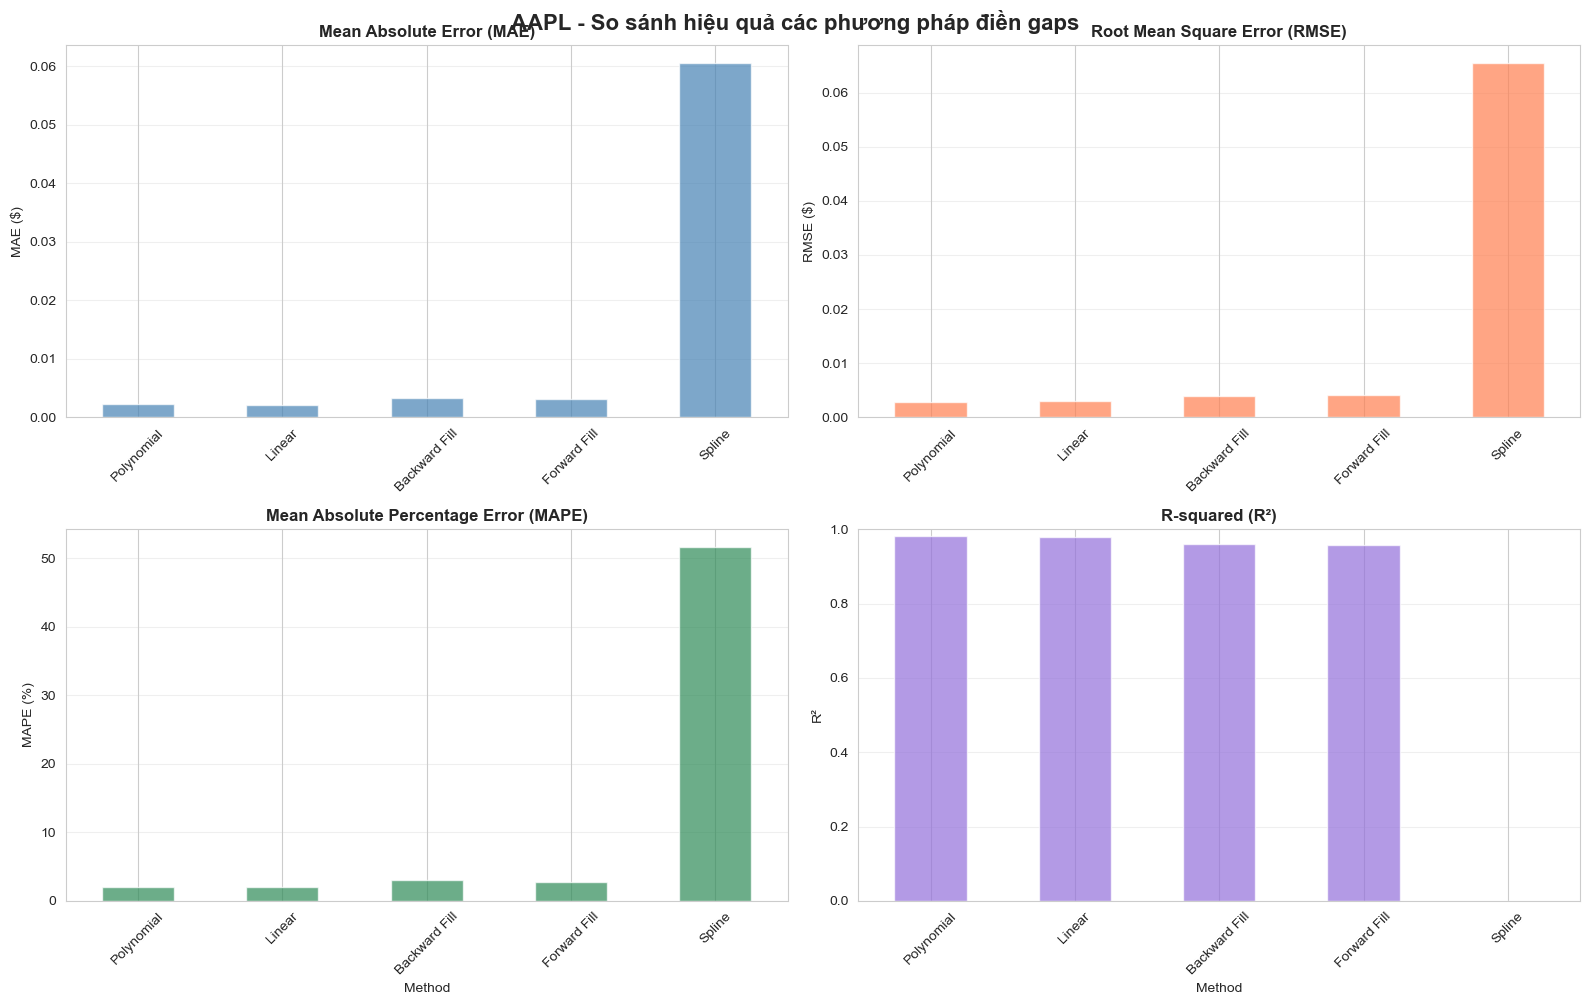

In [64]:
# Visualization: So sánh metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. MAE
results_df.plot(x='Method', y='MAE', kind='bar', ax=axes[0, 0], 
                color='steelblue', alpha=0.7, legend=False)
axes[0, 0].set_title('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('MAE ($)')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. RMSE
results_df.plot(x='Method', y='RMSE', kind='bar', ax=axes[0, 1], 
                color='coral', alpha=0.7, legend=False)
axes[0, 1].set_title('Root Mean Square Error (RMSE)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('RMSE ($)')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. MAPE
results_df.plot(x='Method', y='MAPE (%)', kind='bar', ax=axes[1, 0], 
                color='seagreen', alpha=0.7, legend=False)
axes[1, 0].set_title('Mean Absolute Percentage Error (MAPE)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('MAPE (%)')
axes[1, 0].set_xlabel('Method')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. R²
results_df.plot(x='Method', y='R²', kind='bar', ax=axes[1, 1], 
                color='mediumpurple', alpha=0.7, legend=False)
axes[1, 1].set_title('R-squared (R²)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('R²')
axes[1, 1].set_xlabel('Method')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('AAPL - So sánh hiệu quả các phương pháp điền gaps', 
             fontsize=16, fontweight='bold', y=1.00)
plt.show()

---

# 5. Extracting Time-Based Features (Trích xuất đặc trưng thời gian)

### Mục đích:
- Tạo ra các đặc trưng (features) mới từ dữ liệu thời gian để phục vụ cho machine learning
- Trích xuất các đặc trưng chu kỳ (cyclical features)
- Trích xuất các đặc trưng mùa vụ (seasonal features)
- Kiểm tra tính dừng (stationarity) của chuỗi thời gian

### Lý thuyết:
Mô hình Machine Learning thường không hiểu trực tiếp khái niệm thời gian. Chúng ta cần chuyển đổi thời gian thành các con số có ý nghĩa:
- **Time Components**: Year, Month, Day, Hour... (đã làm ở phần 3)
- **Cyclical Features**: Biến đổi features có tính chu kỳ (Month, DayOfWeek) thành cặp sin/cos để giữ tính liên tục (ví dụ: tháng 12 gần tháng 1)
- **Time Differences**: Khoảng thời gian từ một sự kiện quan trọng
- **Rolling Winndow Features**: (sẽ làm ở phần 6)
    
### Triển khai:
Chúng ta sẽ tiếp tục làm việc với dữ liệu AAPL đã xử lý.


Tạo Time-based Features...
Đã tạo xong các features bổ sung.

Xem mẫu dữ liệu với features mới:


,Month,Month_sin,IsWeekend,IsQuarterEnd,DaysSinceStart
Date,,,,,
1980-12-12,12,-2.449294e-16,0,0,0
1980-12-15,12,-2.449294e-16,0,0,3
1980-12-16,12,-2.449294e-16,0,0,4
1980-12-17,12,-2.449294e-16,0,0,5
1980-12-18,12,-2.449294e-16,0,0,6
1980-12-19,12,-2.449294e-16,0,0,7
1980-12-22,12,-2.449294e-16,0,0,10
1980-12-23,12,-2.449294e-16,0,0,11
1980-12-24,12,-2.449294e-16,0,0,12


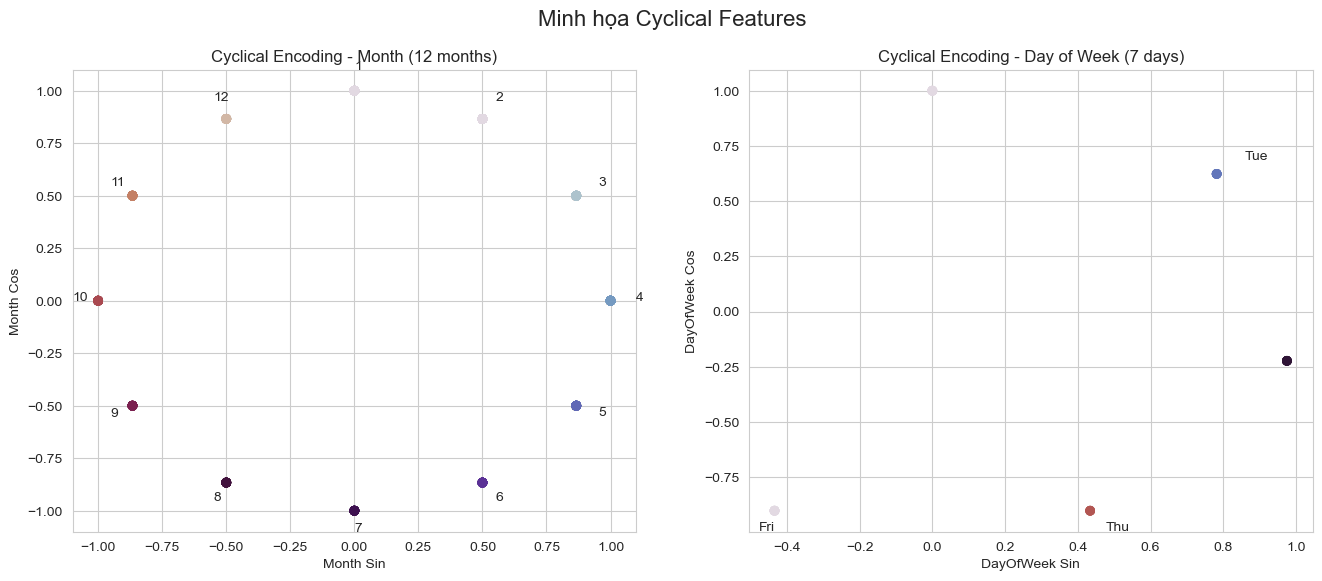


Giải thích:
Việc sử dụng sin/cos giúp mô hình hiểu được tính chu kỳ của thời gian.
Feature mới 'DaysSinceStart' giúp mô hình nắm bắt xu hướng dài hạn (trend) theo thời gian tuyến tính.


In [65]:
# 1. Cyclical Encoding cho Month và DayOfWeek & Indicator Variables
print("Tạo Time-based Features...")

# Tạo copy để không ảnh hưởng dữ liệu gốc
aapl_features = aapl_df.copy()

# --- A. Feature Encoding ---
# Month (1-12)
aapl_features['Month_sin'] = np.sin(2 * np.pi * aapl_features['Month'] / 12)
aapl_features['Month_cos'] = np.cos(2 * np.pi * aapl_features['Month'] / 12)

# DayOfWeek (0-6)
aapl_features['DayOfWeek_sin'] = np.sin(2 * np.pi * aapl_features['DayOfWeek'] / 7)
aapl_features['DayOfWeek_cos'] = np.cos(2 * np.pi * aapl_features['DayOfWeek'] / 7)

# Quarter (1-4)
aapl_features['Quarter_sin'] = np.sin(2 * np.pi * aapl_features['Quarter'] / 4)
aapl_features['Quarter_cos'] = np.cos(2 * np.pi * aapl_features['Quarter'] / 4)

# --- B. Indicator Variables (New) ---
# IsWeekend: 1 nếu là T7/CN, 0 ngược lại (mặc dù dữ liệu chứng khoán thường ko có cuối tuần, nhưng đây là yêu cầu)
aapl_features['IsWeekend'] = aapl_features['DayOfWeek'].isin([5, 6]).astype(int)

cal = USFederalHolidayCalendar()
# Lấy danh sách các ngày lễ trong khoảng thời gian của dataset
holidays = cal.holidays(start=aapl_features.index.min(), end=aapl_features.index.max())
aapl_features['IsHoliday'] = aapl_features.index.isin(holidays).astype(int)

# IsQuarterEnd: 1 nếu là ngày cuối quý
aapl_features['IsQuarterEnd'] = aapl_features.index.is_quarter_end.astype(int)

# --- C. Time Elapsed (New) ---
# Số ngày trôi qua kể từ ngày bắt đầu trong dataset
min_date = aapl_features.index.min()
aapl_features['DaysSinceStart'] = (aapl_features.index - min_date).days

print("Đã tạo xong các features bổ sung.")
print("\nXem mẫu dữ liệu với features mới:")
display(aapl_features[['Month', 'Month_sin', 'IsWeekend', 'IsQuarterEnd', 'DaysSinceStart']].head(12))

# Visualization Cyclical Features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Month Cyclical
axes[0].scatter(aapl_features['Month_sin'][:365], aapl_features['Month_cos'][:365], c=aapl_features['Month'][:365], cmap='twilight')
axes[0].set_title('Cyclical Encoding - Month (12 months)')
axes[0].set_xlabel('Month Sin')
axes[0].set_ylabel('Month Cos')
axes[0].grid(True)
for i, txt in enumerate(range(1, 13)):
    angle = 2 * np.pi * i / 12
    # Simple approx for label placement
    axes[0].annotate(txt, (np.sin(angle)*1.1, np.cos(angle)*1.1))

# DayOfWeek Cyclical
axes[1].scatter(aapl_features['DayOfWeek_sin'][:30], aapl_features['DayOfWeek_cos'][:30], c=aapl_features['DayOfWeek'][:30], cmap='twilight')
axes[1].set_title('Cyclical Encoding - Day of Week (7 days)')
axes[1].set_xlabel('DayOfWeek Sin')
axes[1].set_ylabel('DayOfWeek Cos')
axes[1].grid(True)
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
for i, txt in enumerate(days):
    angle = 2 * np.pi * i / 7
    axes[1].annotate(txt, (np.sin(angle)*1.1, np.cos(angle)*1.1))

plt.suptitle('Minh họa Cyclical Features', fontsize=16)
plt.show()

print("\nGiải thích:")
print("Việc sử dụng sin/cos giúp mô hình hiểu được tính chu kỳ của thời gian.")
print("Feature mới 'DaysSinceStart' giúp mô hình nắm bắt xu hướng dài hạn (trend) theo thời gian tuyến tính.")

---

# 6. Resampling Time Series (Lấy mẫu lại dữ liệu)

### Mục đích:
- Thay đổi tần suất của dữ liệu (ví dụ: từ ngày sang tuần, tháng, năm)
- Downsampling: Giảm tần suất (Ngày -> Tháng) để tổng hợp dữ liệu
- Upsampling: Tăng tần suất (Tháng -> Ngày) để chi tiết hóa dữ liệu

### Giải thích:
Pandas cung cấp hàm `resample()` hoạt động tương tự như `groupby()` nhưng chuyên biệt cho index thời gian.
- **Aggregation**: mean(), sum(), min(), max(), first(), last()...
- **OHLC**: Open-High-Low-Close resampling thường dùng trong tài chính


Thực hiện Downsampling AAPL Data...
Dữ liệu gốc (Daily): 10590 dòng
Dữ liệu Monthly: 505 dòng
Dữ liệu Yearly: 43 dòng

Dữ liệu tổng hợp theo Tháng:


,Open,High,Low,Close,Volume
Date,,,,,
1980-12-31,0.128348,0.161272,0.112723,0.152344,1344851200
1981-01-31,0.154018,0.155134,0.126116,0.126116,608988800
1981-02-28,0.119420,0.128906,0.106027,0.118304,321619200
1981-03-31,0.118862,0.120536,0.096540,0.109375,700716800
1981-04-30,0.108817,0.131138,0.108259,0.126674,536928000


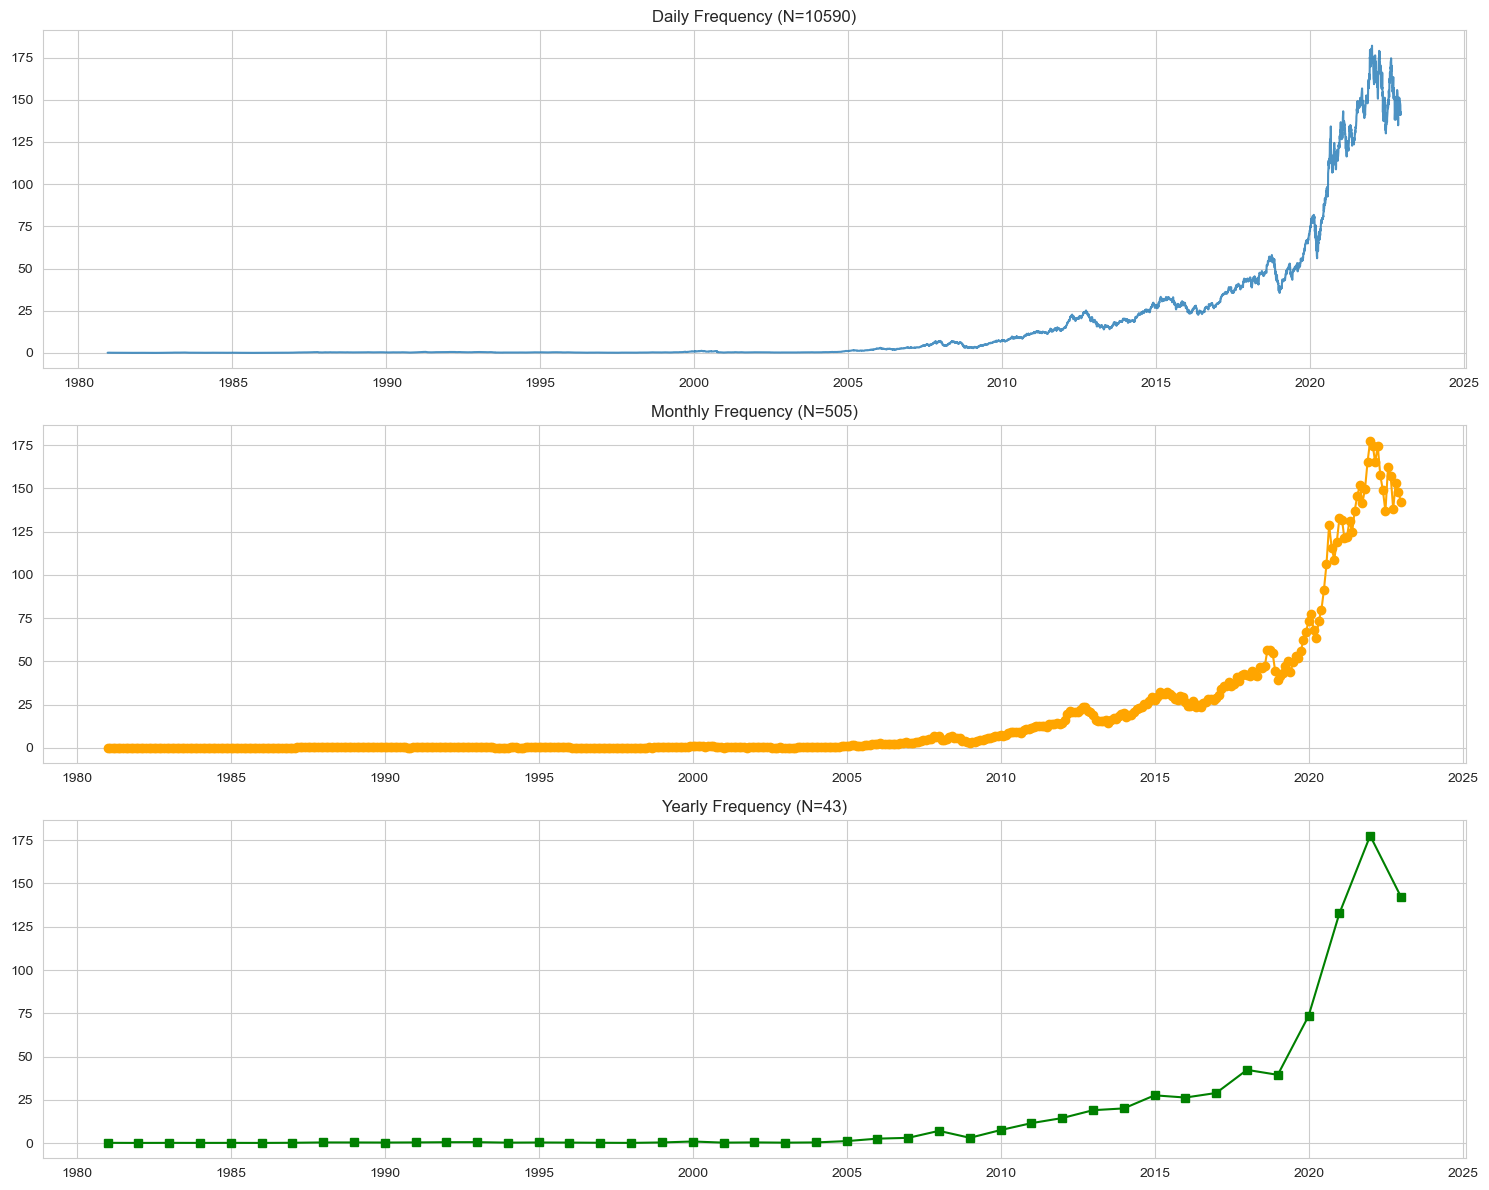

In [66]:
# 1. Downsampling: Tổng hợp dữ liệu theo Tháng và Năm
print("Thực hiện Downsampling AAPL Data...")

# Resample theo Tháng (M=Month End)
# Tính trung bình cho giá và tổng cho volume
monthly_aapl = aapl_df.resample('M').agg({
    'Open': 'first',      # Giá mở cửa đầu tháng
    'High': 'max',        # Giá cao nhất trong tháng
    'Low': 'min',         # Giá thấp nhất trong tháng
    'Close': 'last',      # Giá đóng cửa cuối tháng
    'Volume': 'sum'       # Tổng khối lượng giao dịch cả tháng
})

# Resample theo Năm (Y=Year End)
yearly_aapl = aapl_df.resample('Y').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
})

print(f"Dữ liệu gốc (Daily): {len(aapl_df)} dòng")
print(f"Dữ liệu Monthly: {len(monthly_aapl)} dòng")
print(f"Dữ liệu Yearly: {len(yearly_aapl)} dòng")

# Hiển thị mẫu
print("\nDữ liệu tổng hợp theo Tháng:")
display(monthly_aapl.head())

# Visualization so sánh frequencies
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Daily
axes[0].plot(aapl_df.index, aapl_df['Close'], alpha=0.8)
axes[0].set_title(f'Daily Frequency (N={len(aapl_df)})')

# Monthly
axes[1].plot(monthly_aapl.index, monthly_aapl['Close'], marker='o', color='orange')
axes[1].set_title(f'Monthly Frequency (N={len(monthly_aapl)})')

# Yearly
axes[2].plot(yearly_aapl.index, yearly_aapl['Close'], marker='s', color='green')
axes[2].set_title(f'Yearly Frequency (N={len(yearly_aapl)})')

plt.tight_layout()
plt.show()


---

# 7. Lag Features, Rolling Window & Autocorrelation (Đặc trưng trễ, cửa sổ trượt & Tự tương quan)

### Mục đích:
- **Lag Features**: Sử dụng giá trị quá khứ để dự báo tương lai (Past Predicts Future)
- **Rolling Window Statistics**: Tính toán thống kê trên cửa sổ trượt (Moving Average, Rolling Std) để làm mượt nhiễu và đo lường biến động
- **Autocorrelation (ACF)**: Đo lường mức độ tương quan giữa chuỗi số liệu và chính nó ở quá khứ
- **Partial Autocorrelation (PACF)**: Tương quan riêng phần sau khi loại bỏ ảnh hưởng của các lags trung gian

### Giải thích:
Trong Time Series Forecasting (ví dụ LSTM, ARIMA), việc sử dụng giá trị quá khứ làm input là kỹ thuật cơ bản nhất.
- Lag 1: Giá hôm qua
- Lag 7: Giá tuần trước
- Lag 365: Giá năm ngoái
- Rolling Mean (SMA): Trung bình trượt giúp làm mượt xu hướng
- Rolling Std: Độ lệch chuẩn trượt đo lường biến động (volatility)


Tạo Lag Features cho AAPL...
DIFFERENCE FEATURES

Diff_Close  = Close(t) - Close(t-1)  →  biến động giá tuyệt đối
Diff2_Close = Diff(t) - Diff(t-1)   →  gia tốc biến động giá

Mẫu Difference Features:


,Close,Diff_Close,Diff2_Close
Date,,,
1980-12-12,0.128348,NaN,NaN
1980-12-15,0.121652,-0.006696,NaN
1980-12-16,0.112723,-0.008929,-0.002233
1980-12-17,0.115513,0.002790,0.011719
1980-12-18,0.118862,0.003349,0.000559
1980-12-19,0.126116,0.007254,0.003905
1980-12-22,0.132254,0.006138,-0.001116
1980-12-23,0.137835,0.005581,-0.000557
1980-12-24,0.145089,0.007254,0.001673


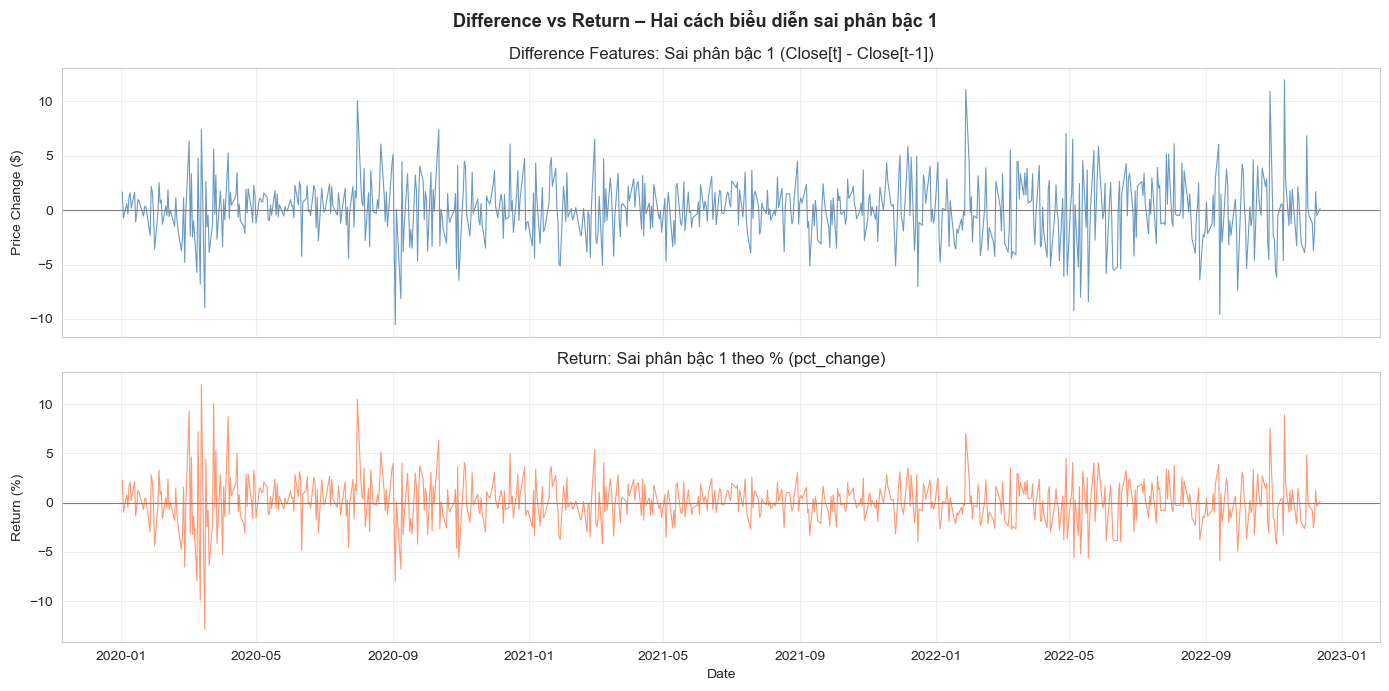


Nhận xét:
- Diff_Close (tuyệt đối): dễ bị ảnh hưởng bởi mức giá → cổ phiếu đắt có diff lớn hơn.
- Return (phần trăm): chuẩn hóa theo mức giá → so sánh được giữa các cổ phiếu.
- Cả hai đều là chuỗi dừng (stationary) phù hợp để phân tích ACF/PACF.

Mẫu dữ liệu với Lag Features (Returns):


,Close,Return,Return_Lag_1,Return_Lag_2,Return_Lag_3
Date,,,,,
1980-12-12,0.128348,NaN,NaN,NaN,NaN
1980-12-15,0.121652,-0.052171,NaN,NaN,NaN
1980-12-16,0.112723,-0.073398,-0.052171,NaN,NaN
1980-12-17,0.115513,0.024751,-0.073398,-0.052171,NaN
1980-12-18,0.118862,0.028992,0.024751,-0.073398,-0.052171
1980-12-19,0.126116,0.061029,0.028992,0.024751,-0.073398
1980-12-22,0.132254,0.048670,0.061029,0.028992,0.024751
1980-12-23,0.137835,0.042199,0.048670,0.061029,0.028992
1980-12-24,0.145089,0.052628,0.042199,0.048670,0.061029


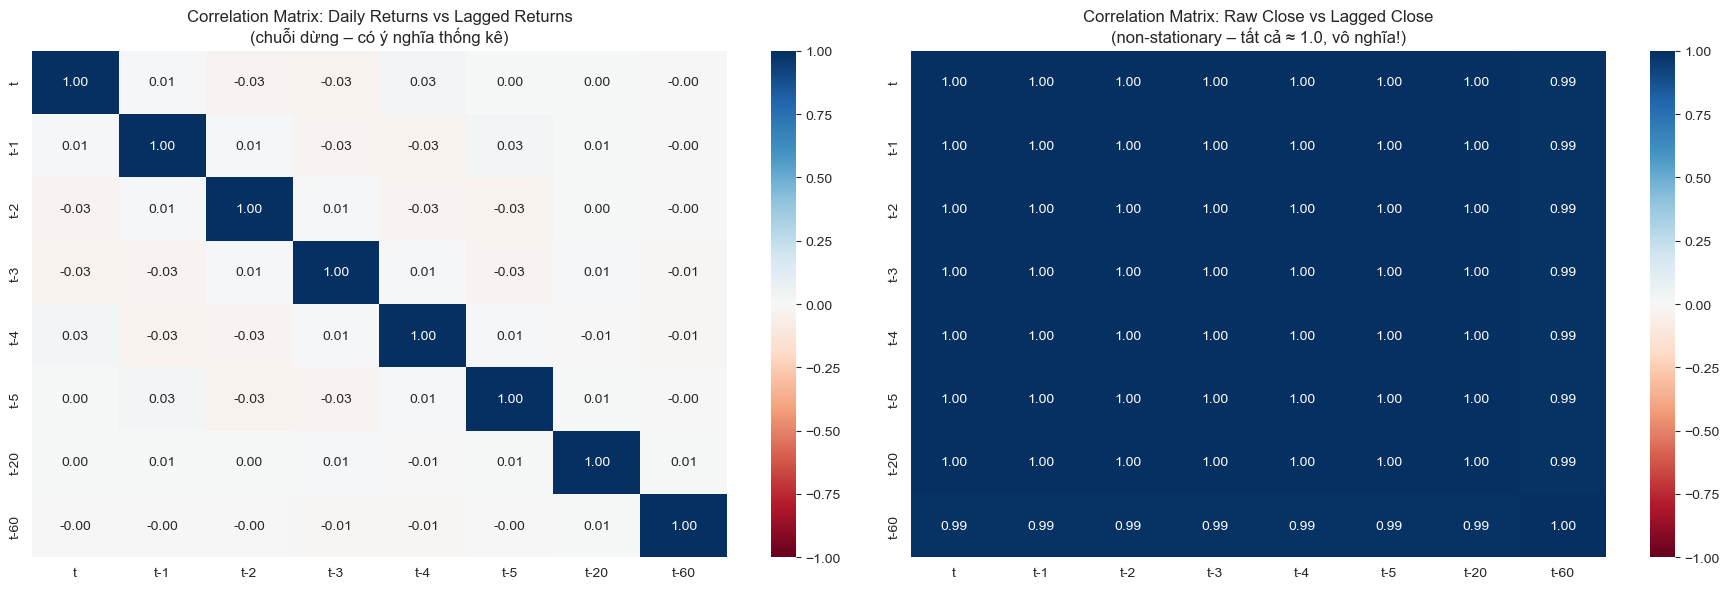


Nhận xét:
- Heatmap RAW CLOSE: tất cả giá trị ≈ 1.0 do xu hướng (trend) chi phối → không phân biệt được ý nghĩa của từng lag.
- Heatmap RETURNS: tương quan giữa return hiện tại và các lag rất thấp (~0),
  phù hợp với Efficient Market Hypothesis – giá cổ phiếu gần như là random walk.
  Đây mới là thông tin có ý nghĩa để quyết định chọn lag nào.

THẢO LUẬN: TỰ TƯƠNG QUAN & LỰA CHỌN LAG PHÙ HỢP

Ngưỡng ý nghĩa thống kê (95% CI): ±0.0190

Các lag có ACF  có ý nghĩa thống kê (top 10): [2, 3, 4, 10, 12, 22]
Các lag có PACF có ý nghĩa thống kê (top 10): [2, 3, 4, 10, 12]


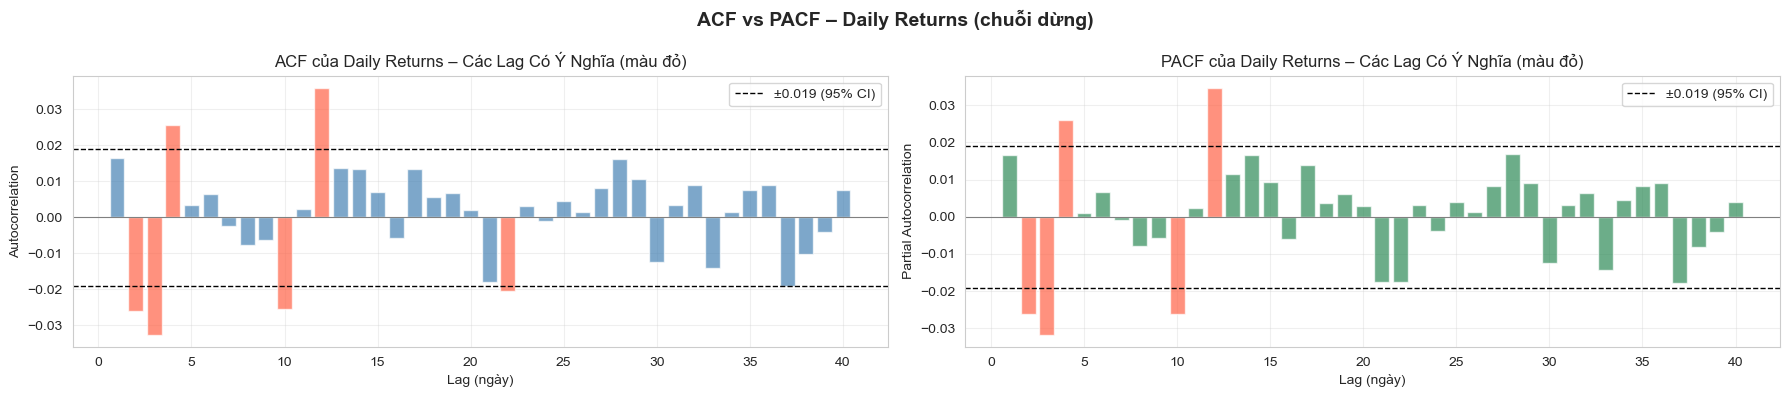


Lý do lựa chọn giá trị lag:
─────────────────────────────────────────────────────────────────────────────
1. Dựa trên ACF / PACF (áp dụng trên chuỗi dừng – Returns):
   - Lag nằm ngoài vùng tin cậy 95% (đường đứt nét) là lag có ý nghĩa thống kê
     và nên được đưa vào mô hình.
   - ACF giảm chậm trên raw Close → chuỗi chưa dừng, cần dùng Returns.
   - PACF cắt đột ngột sau lag k → gợi ý dùng AR(k).

2. Dựa trên kiến thức miền (Domain Knowledge):
   - Lag 1  : Return ngày hôm qua – short-term momentum.
   - Lag 5  : Return tuần trước – weekly pattern.
   - Lag 20 : Return tháng trước – monthly trend.
   - Lag 60 : Return quý trước – quarterly cycle.

3. Tránh multicollinearity:
   - Các lag liên tiếp (1, 2, 3…) thường tương quan cao với nhau.
   - Nên chọn một tập lag đại diện thay vì tất cả để giảm nhiễu cho mô hình.

4. Cross-validation:
   - Kiểm tra tác động thực tế của từng lag bằng cách đưa vào mô hình dự báo
     rồi đánh giá MAE / RMSE trên tập validation.
────────────────────

In [67]:
# 1. Tạo Lag Features
print("Tạo Lag Features cho AAPL...")

# Tính Daily Returns (chuỗi dừng)
aapl_features['Return'] = aapl_features['Close'].pct_change()

# Tạo lag features trên Returns
for i in range(1, 6):
    aapl_features[f'Return_Lag_{i}'] = aapl_features['Return'].shift(i)

aapl_features['Return_Lag_20'] = aapl_features['Return'].shift(20)
aapl_features['Return_Lag_60'] = aapl_features['Return'].shift(60)

# (Vẫn giữ lag trên Close để dùng cho mô hình)
for i in range(1, 6):
    aapl_features[f'Lag_{i}'] = aapl_features['Close'].shift(i)
aapl_features['Lag_20'] = aapl_features['Close'].shift(20)
aapl_features['Lag_60'] = aapl_features['Close'].shift(60)

# --- Difference Features ---
# Sai phân bậc 1: biến động giá tuyệt đối so với ngày trước
aapl_features['Diff_Close'] = aapl_features['Close'].diff()
# Sai phân bậc 2: tốc độ thay đổi của biến động
aapl_features['Diff2_Close'] = aapl_features['Close'].diff().diff()

print("=" * 60)
print("DIFFERENCE FEATURES")
print("=" * 60)
print("\nDiff_Close  = Close(t) - Close(t-1)  →  biến động giá tuyệt đối")
print("Diff2_Close = Diff(t) - Diff(t-1)   →  gia tốc biến động giá")
print("\nMẫu Difference Features:")
display(aapl_features[['Close', 'Diff_Close', 'Diff2_Close']].head(10))

# So sánh: pct_change (Return) vs diff (Diff_Close)
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
subset_diff = aapl_features.loc['2020-01-01':, ['Close', 'Return', 'Diff_Close']].dropna()
axes[0].plot(subset_diff.index, subset_diff['Diff_Close'], color='steelblue', linewidth=0.8, alpha=0.8)
axes[0].set_title('Difference Features: Sai phân bậc 1 (Close[t] - Close[t-1])', fontsize=12)
axes[0].set_ylabel('Price Change ($)')
axes[0].axhline(0, color='gray', linewidth=0.8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(subset_diff.index, subset_diff['Return'] * 100, color='coral', linewidth=0.8, alpha=0.8)
axes[1].set_title('Return: Sai phân bậc 1 theo % (pct_change)', fontsize=12)
axes[1].set_ylabel('Return (%)')
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Difference vs Return – Hai cách biểu diễn sai phân bậc 1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNhận xét:")
print("- Diff_Close (tuyệt đối): dễ bị ảnh hưởng bởi mức giá → cổ phiếu đắt có diff lớn hơn.")
print("- Return (phần trăm): chuẩn hóa theo mức giá → so sánh được giữa các cổ phiếu.")
print("- Cả hai đều là chuỗi dừng (stationary) phù hợp để phân tích ACF/PACF.")

print("\nMẫu dữ liệu với Lag Features (Returns):")
display(aapl_features[['Close', 'Return', 'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3']].head(10))

# Drop NaN
return_lags_df = aapl_features[['Return', 'Return_Lag_1', 'Return_Lag_2',
                                  'Return_Lag_3', 'Return_Lag_4', 'Return_Lag_5',
                                  'Return_Lag_20', 'Return_Lag_60']].dropna()

# Rename để heatmap gọn hơn
return_lags_df.columns = ['t', 't-1', 't-2', 't-3', 't-4', 't-5', 't-20', 't-60']

# 2. Correlation Matrix trên Returns (có ý nghĩa hơn)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap Returns lags
sns.heatmap(return_lags_df.corr(), annot=True, cmap='RdBu', fmt='.2f',
            vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlation Matrix: Daily Returns vs Lagged Returns\n(chuỗi dừng – có ý nghĩa thống kê)', fontsize=12)

# So sánh: Close lags (non-stationary – sai lầm phổ biến)
close_lags_df = aapl_features[['Close', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_4', 'Lag_5', 'Lag_20', 'Lag_60']].dropna()
close_lags_df.columns = ['t', 't-1', 't-2', 't-3', 't-4', 't-5', 't-20', 't-60']
sns.heatmap(close_lags_df.corr(), annot=True, cmap='RdBu', fmt='.2f',
            vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Correlation Matrix: Raw Close vs Lagged Close\n(non-stationary – tất cả ≈ 1.0, vô nghĩa!)', fontsize=12)

plt.tight_layout()
plt.show()

print("\nNhận xét:")
print("- Heatmap RAW CLOSE: tất cả giá trị ≈ 1.0 do xu hướng (trend) chi phối → không phân biệt được ý nghĩa của từng lag.")
print("- Heatmap RETURNS: tương quan giữa return hiện tại và các lag rất thấp (~0),")
print("  phù hợp với Efficient Market Hypothesis – giá cổ phiếu gần như là random walk.")
print("  Đây mới là thông tin có ý nghĩa để quyết định chọn lag nào.")

# ─────────────────────────────────────────────────────────────────────────────
# Thảo luận: Tự tương quan (Autocorrelation) & Lựa chọn Lag phù hợp
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("THẢO LUẬN: TỰ TƯƠNG QUAN & LỰA CHỌN LAG PHÙ HỢP")
print("="*70)

from statsmodels.tsa.stattools import acf, pacf

# Tính ACF và PACF trên chuỗi sai phân (stationary) để có kết quả có ý nghĩa hơn
diff_close = aapl_features['Return'].dropna()

acf_values  = acf(diff_close,  nlags=40, fft=True)
pacf_values = pacf(diff_close, nlags=40)

# Ngưỡng ý nghĩa thống kê (95% confidence interval)
significance_level = 1.96 / np.sqrt(len(diff_close))

# Tìm các lag có |ACF| > ngưỡng
significant_acf_lags  = [i for i, v in enumerate(acf_values[1:], 1)  if abs(v) > significance_level]
significant_pacf_lags = [i for i, v in enumerate(pacf_values[1:], 1) if abs(v) > significance_level]

print(f"\nNgưỡng ý nghĩa thống kê (95% CI): ±{significance_level:.4f}")
print(f"\nCác lag có ACF  có ý nghĩa thống kê (top 10): {significant_acf_lags[:10]}")
print(f"Các lag có PACF có ý nghĩa thống kê (top 10): {significant_pacf_lags[:10]}")

# Visualize ACF và PACF – bar chart cạnh nhau
fig, (ax_acf, ax_pacf) = plt.subplots(1, 2, figsize=(18, 4))

# ACF bar chart
ax_acf.bar(range(1, 41), acf_values[1:],
           color=['tomato' if abs(v) > significance_level else 'steelblue'
                  for v in acf_values[1:]], alpha=0.7)
ax_acf.axhline(y= significance_level, linestyle='--', color='black', linewidth=1,
               label=f'±{significance_level:.3f} (95% CI)')
ax_acf.axhline(y=-significance_level, linestyle='--', color='black', linewidth=1)
ax_acf.axhline(y=0, color='gray', linewidth=0.8)
ax_acf.set_title('ACF của Daily Returns – Các Lag Có Ý Nghĩa (màu đỏ)', fontsize=12)
ax_acf.set_xlabel('Lag (ngày)')
ax_acf.set_ylabel('Autocorrelation')
ax_acf.legend()
ax_acf.grid(True, alpha=0.3)

# PACF bar chart
ax_pacf.bar(range(1, 41), pacf_values[1:],
            color=['tomato' if abs(v) > significance_level else 'seagreen'
                   for v in pacf_values[1:]], alpha=0.7)
ax_pacf.axhline(y= significance_level, linestyle='--', color='black', linewidth=1,
                label=f'±{significance_level:.3f} (95% CI)')
ax_pacf.axhline(y=-significance_level, linestyle='--', color='black', linewidth=1)
ax_pacf.axhline(y=0, color='gray', linewidth=0.8)
ax_pacf.set_title('PACF của Daily Returns – Các Lag Có Ý Nghĩa (màu đỏ)', fontsize=12)
ax_pacf.set_xlabel('Lag (ngày)')
ax_pacf.set_ylabel('Partial Autocorrelation')
ax_pacf.legend()
ax_pacf.grid(True, alpha=0.3)

plt.suptitle('ACF vs PACF – Daily Returns (chuỗi dừng)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Lý do lựa chọn giá trị lag:
─────────────────────────────────────────────────────────────────────────────
1. Dựa trên ACF / PACF (áp dụng trên chuỗi dừng – Returns):
   - Lag nằm ngoài vùng tin cậy 95% (đường đứt nét) là lag có ý nghĩa thống kê
     và nên được đưa vào mô hình.
   - ACF giảm chậm trên raw Close → chuỗi chưa dừng, cần dùng Returns.
   - PACF cắt đột ngột sau lag k → gợi ý dùng AR(k).

2. Dựa trên kiến thức miền (Domain Knowledge):
   - Lag 1  : Return ngày hôm qua – short-term momentum.
   - Lag 5  : Return tuần trước – weekly pattern.
   - Lag 20 : Return tháng trước – monthly trend.
   - Lag 60 : Return quý trước – quarterly cycle.

3. Tránh multicollinearity:
   - Các lag liên tiếp (1, 2, 3…) thường tương quan cao với nhau.
   - Nên chọn một tập lag đại diện thay vì tất cả để giảm nhiễu cho mô hình.

4. Cross-validation:
   - Kiểm tra tác động thực tế của từng lag bằng cách đưa vào mô hình dự báo
     rồi đánh giá MAE / RMSE trên tập validation.
─────────────────────────────────────────────────────────────────────────────
""")

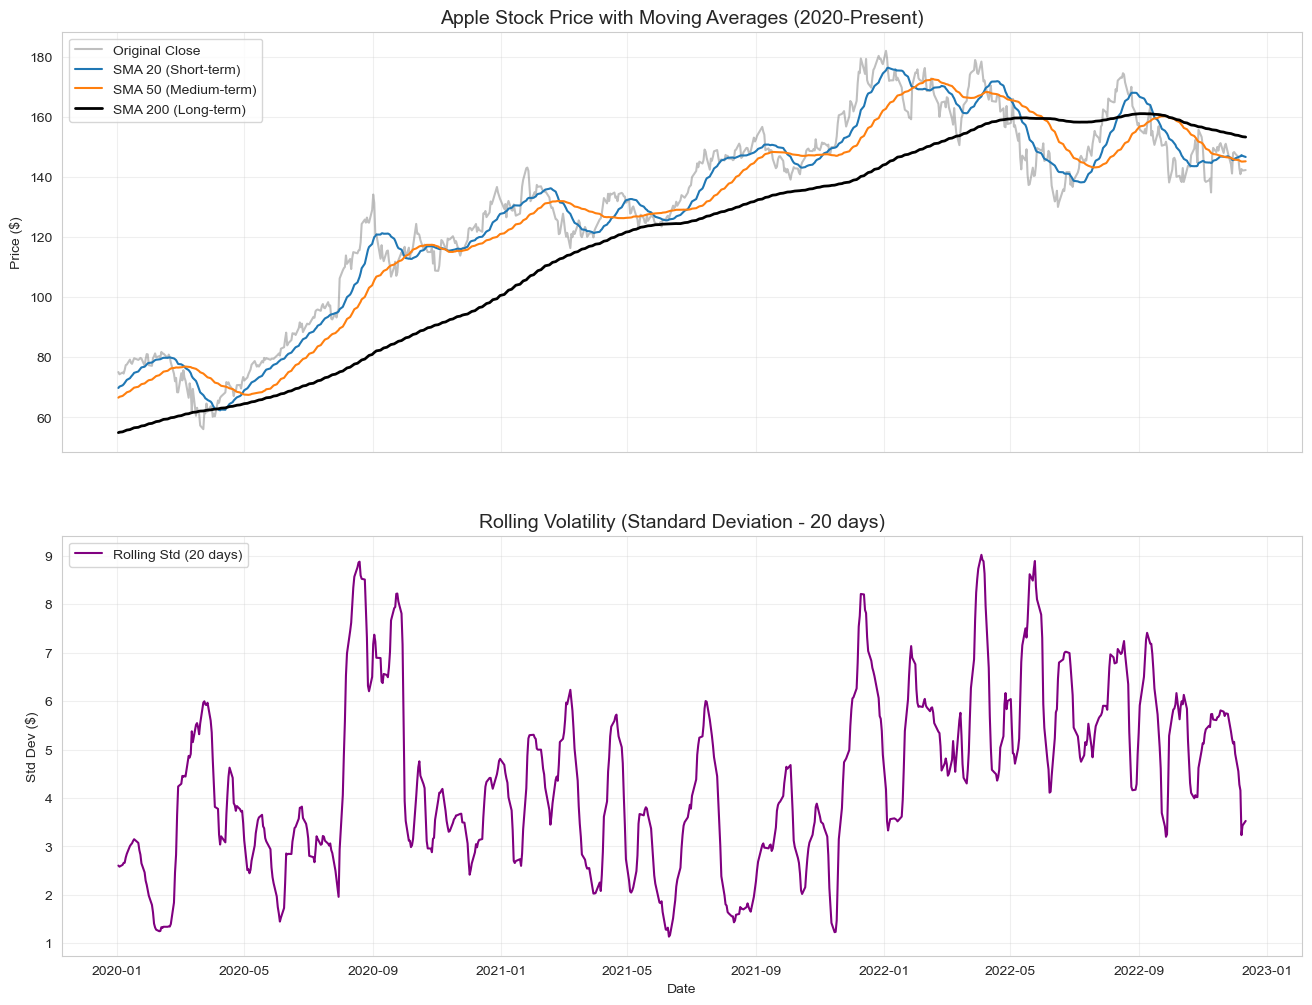

Nhận xét:
- SMA 20 bám sát giá rất tốt nhưng vẫn còn nhiều biến động.
- SMA 200 rất mượt, thể hiện xu hướng dài hạn.
- Rolling Std tăng cao trong những giai đoạn giá biến động mạnh (ví dụ đầu năm 2020 do Covid-19).
- Điểm giao cắt giữa SMA ngắn hạn và SMA dài hạn (Golden Cross / Death Cross) thường được dùng làm tín hiệu giao dịch.


In [68]:
# 3. Rolling Window Statistics (Moving Average & Rolling Std)
# Đây là kỹ thuật Smoothing phổ biến và đo lường biến động (Volatility)

# A. Tính Rolling Mean (Simple Moving Average - SMA)
# Window = 20 ngày (~1 tháng giao dịch)
aapl_df['SMA_20'] = aapl_df['Close'].rolling(window=20).mean()

# Window = 50 ngày (~1 quý)
aapl_df['SMA_50'] = aapl_df['Close'].rolling(window=50).mean()

# Window = 200 ngày (~1 năm)
aapl_df['SMA_200'] = aapl_df['Close'].rolling(window=200).mean()

# B. Tính Rolling Standard Deviation (New)
# Đo lường sự biến động (volatility) trong khoảng thời gian 20 ngày (Bollinger Bands component)
aapl_df['Rol_Std_20'] = aapl_df['Close'].rolling(window=20).std()

# Visualization Rolling Means & Std
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Plot 1: Price & SMA
# Lấy dữ liệu 2 năm gần nhất để nhìn rõ hơn
subset = aapl_df.loc['2020-01-01':]

ax1.plot(subset.index, subset['Close'], label='Original Close', alpha=0.5, color='gray')
ax1.plot(subset.index, subset['SMA_20'], label='SMA 20 (Short-term)', linewidth=1.5)
ax1.plot(subset.index, subset['SMA_50'], label='SMA 50 (Medium-term)', linewidth=1.5)
ax1.plot(subset.index, subset['SMA_200'], label='SMA 200 (Long-term)', linewidth=2, color='black')

ax1.set_title('Apple Stock Price with Moving Averages (2020-Present)', fontsize=14)
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Rolling Standard Deviation (Volatility)
ax2.plot(subset.index, subset['Rol_Std_20'], label='Rolling Std (20 days)', color='purple', linewidth=1.5)
ax2.set_title('Rolling Volatility (Standard Deviation - 20 days)', fontsize=14)
ax2.set_xlabel('Date')
ax2.set_ylabel('Std Dev ($)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.show()

print("Nhận xét:")
print("- SMA 20 bám sát giá rất tốt nhưng vẫn còn nhiều biến động.")
print("- SMA 200 rất mượt, thể hiện xu hướng dài hạn.")
print("- Rolling Std tăng cao trong những giai đoạn giá biến động mạnh (ví dụ đầu năm 2020 do Covid-19).")
print("- Điểm giao cắt giữa SMA ngắn hạn và SMA dài hạn (Golden Cross / Death Cross) thường được dùng làm tín hiệu giao dịch.")


---

# 8. Tổng kết

### Tổng kết
Chúng ta đã hoàn thành quy trình xử lý dữ liệu thời gian cơ bản:
1. **Parsing**: Chuyển đổi string sang datetime, set index.
2. **Handling Gaps**: Xử lý dữ liệu bị thiếu trong chuỗi thời gian.
3. **Feature Extraction**: Tạo ra các biến time components, cyclical features.
4. **Resampling**: Thay đổi khung thời gian (Daily -> Monthly).
5. **Lag, Rolling Window & Autocorrelation**: Khai thác mối quan hệ quá khứ - hiện tại, làm mượt dữ liệu và đo lường biến động.
